**Introduction:**

In the modern maritime industry, the ability to distinguish between rocks and potential underwater mines is crucial for safe navigation. We are
part of a marine research team tasked with developing an Al-based system to classify sonar readings accurately. Our goal is to create a logistic regression model capable of distinguishing between *Rocks* and *Mines* based on sonar data.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/UCI_Sonar_Dataset.csv', header = None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.036001,0.018991,0.015828,0.061831,0.091641,0.061453,0.096639,0.096555,0.172024,0.202207,...,0.006571,0.017710,0.020391,0.015693,0.010744,0.010397,0.008481,0.009784,0.005001,R
1,0.010467,0.001375,0.000000,0.000000,0.000000,0.035272,0.133258,0.182611,0.243905,0.307986,...,0.000000,0.000000,0.004677,0.006382,0.009028,0.006642,0.005931,0.000078,0.003062,M
2,0.031195,0.029851,0.015650,0.040368,0.064748,0.088087,0.119909,0.118584,0.132309,0.130649,...,0.009625,0.016117,0.010236,0.008164,0.011349,0.007432,0.008796,0.008608,0.009208,R
3,0.054236,0.086304,0.081407,0.092921,0.091274,0.097645,0.122464,0.182208,0.298539,0.301516,...,0.012304,0.006648,0.012478,0.008327,0.006552,0.004455,0.001682,0.004501,0.002634,M
4,0.026964,0.038721,0.051162,0.073747,0.100574,0.157899,0.143043,0.159353,0.164889,0.175796,...,0.019562,0.009628,0.006016,0.007638,0.004513,0.008703,0.011612,0.011428,0.008633,R


In [95]:
sonar_data = dataset.copy()
feature_names = [
    f'Sonar_Feature_{i:02d}'
    for i in range(1,61)
]
sonar_data.columns = feature_names + ['Target']

sonar_data.head()

,Sonar_Feature_01,Sonar_Feature_02,Sonar_Feature_03,Sonar_Feature_04,Sonar_Feature_05,Sonar_Feature_06,Sonar_Feature_07,Sonar_Feature_08,Sonar_Feature_09,Sonar_Feature_10,...,Sonar_Feature_52,Sonar_Feature_53,Sonar_Feature_54,Sonar_Feature_55,Sonar_Feature_56,Sonar_Feature_57,Sonar_Feature_58,Sonar_Feature_59,Sonar_Feature_60,Target
0,0.036001,0.018991,0.015828,0.061831,0.091641,0.061453,0.096639,0.096555,0.172024,0.202207,...,0.006571,0.017710,0.020391,0.015693,0.010744,0.010397,0.008481,0.009784,0.005001,R
1,0.010467,0.001375,0.000000,0.000000,0.000000,0.035272,0.133258,0.182611,0.243905,0.307986,...,0.000000,0.000000,0.004677,0.006382,0.009028,0.006642,0.005931,0.000078,0.003062,M
2,0.031195,0.029851,0.015650,0.040368,0.064748,0.088087,0.119909,0.118584,0.132309,0.130649,...,0.009625,0.016117,0.010236,0.008164,0.011349,0.007432,0.008796,0.008608,0.009208,R
3,0.054236,0.086304,0.081407,0.092921,0.091274,0.097645,0.122464,0.182208,0.298539,0.301516,...,0.012304,0.006648,0.012478,0.008327,0.006552,0.004455,0.001682,0.004501,0.002634,M
4,0.026964,0.038721,0.051162,0.073747,0.100574,0.157899,0.143043,0.159353,0.164889,0.175796,...,0.019562,0.009628,0.006016,0.007638,0.004513,0.008703,0.011612,0.011428,0.008633,R


In [96]:
print("Shape:",sonar_data.shape)

Shape: (3000, 61)


In [97]:
sonar_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 61 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sonar_Feature_01  2990 non-null   float64
 1   Sonar_Feature_02  2994 non-null   float64
 2   Sonar_Feature_03  2991 non-null   float64
 3   Sonar_Feature_04  2992 non-null   float64
 4   Sonar_Feature_05  2992 non-null   float64
 5   Sonar_Feature_06  2991 non-null   float64
 6   Sonar_Feature_07  2994 non-null   float64
 7   Sonar_Feature_08  2994 non-null   float64
 8   Sonar_Feature_09  2992 non-null   float64
 9   Sonar_Feature_10  2993 non-null   float64
 10  Sonar_Feature_11  2993 non-null   float64
 11  Sonar_Feature_12  2991 non-null   float64
 12  Sonar_Feature_13  2992 non-null   float64
 13  Sonar_Feature_14  2993 non-null   float64
 14  Sonar_Feature_15  2994 non-null   float64
 15  Sonar_Feature_16  2991 non-null   float64
 16  Sonar_Feature_17  2992 non-null   float64


In [98]:
sonar_data.describe()

,Sonar_Feature_01,Sonar_Feature_02,Sonar_Feature_03,Sonar_Feature_04,Sonar_Feature_05,Sonar_Feature_06,Sonar_Feature_07,Sonar_Feature_08,Sonar_Feature_09,Sonar_Feature_10,...,Sonar_Feature_51,Sonar_Feature_52,Sonar_Feature_53,Sonar_Feature_54,Sonar_Feature_55,Sonar_Feature_56,Sonar_Feature_57,Sonar_Feature_58,Sonar_Feature_59,Sonar_Feature_60
count,2990.000000,2994.000000,2991.000000,2992.000000,2992.000000,2991.000000,2994.000000,2994.000000,2992.000000,2993.000000,...,2996.000000,2995.000000,2995.000000,2993.000000,2991.000000,2989.000000,2995.000000,2992.000000,2992.000000,2996.000000
mean,0.030223,0.039639,0.045612,0.055535,0.075881,0.104677,0.121290,0.135796,0.176961,0.206133,...,0.016378,0.013866,0.011050,0.010941,0.009336,0.008059,0.007780,0.007784,0.008028,0.006662
std,0.018869,0.025801,0.030049,0.035620,0.043849,0.047400,0.050314,0.067874,0.099087,0.112796,...,0.010009,0.008047,0.005930,0.006020,0.005670,0.004452,0.004437,0.004968,0.004781,0.003959
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.016788,0.020674,0.022822,0.029098,0.043820,0.072621,0.087266,0.089531,0.105119,0.123641,...,0.009099,0.008119,0.006931,0.006738,0.005174,0.004733,0.004636,0.004260,0.004637,0.003842
50%,0.028087,0.036920,0.042548,0.052420,0.073544,0.102920,0.121112,0.134775,0.170489,0.199658,...,0.015030,0.012968,0.010848,0.010640,0.009067,0.007982,0.007745,0.007350,0.007799,0.006429
75%,0.041441,0.055387,0.064758,0.078504,0.105088,0.136699,0.155572,0.180826,0.241723,0.279354,...,0.022502,0.018849,0.014831,0.014588,0.012968,0.011061,0.010795,0.010933,0.010893,0.009129
max,0.117449,0.155125,0.171502,0.188097,0.238220,0.269322,0.318866,0.387755,0.560627,0.636330,...,0.059975,0.047986,0.033146,0.036188,0.034172,0.024452,0.025949,0.028348,0.027011,0.022637


In [135]:
# Check missing values

missing_values = sonar_data.isnull().sum()
print('Total null value:',missing_values.sum())
# 2nd sum() is used to total all missing values across the entire DataFrame

print("\nColumns with missing values:")
missing_values[missing_values>0].sort_values(ascending=False)

Total null value: 486

Columns with missing values:


,0
Sonar_Feature_25,17
Sonar_Feature_35,17
Sonar_Feature_31,14
Sonar_Feature_22,14
Sonar_Feature_27,13
Sonar_Feature_33,12
Sonar_Feature_38,11
Sonar_Feature_56,11
Sonar_Feature_50,11
Sonar_Feature_24,10


In [100]:
# Checking missing values in Target Column
print('Total null values in Target Column:',sonar_data['Target'].isnull().sum())

Total null values in Target Column: 0


In [101]:
print('Total duplicate values:',sonar_data.duplicated().sum())

Total duplicate values: 0


In [136]:
# Check value counts of Target Columns
sonar_data['Target'].value_counts()

,count
Target,
1,1637
0,1363


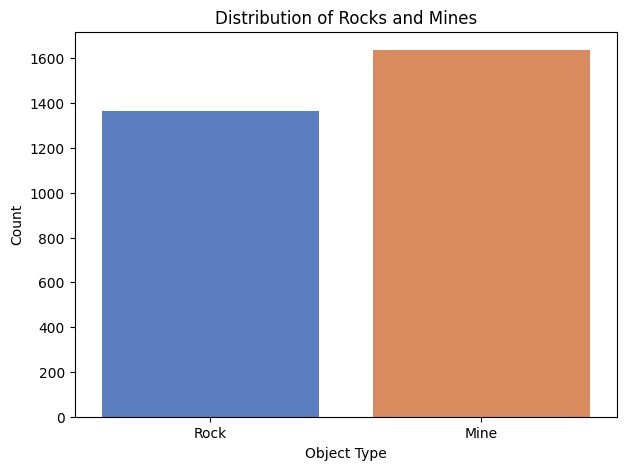

In [137]:
# Target Distribution

plt.figure(figsize=(7,5))
sns.countplot(x = sonar_data['Target'], hue = sonar_data['Target'], palette= 'muted', legend = False)
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.title('Distribution of Rocks and Mines')
plt.xticks([0,1],['Rock', 'Mine'])
plt.show()

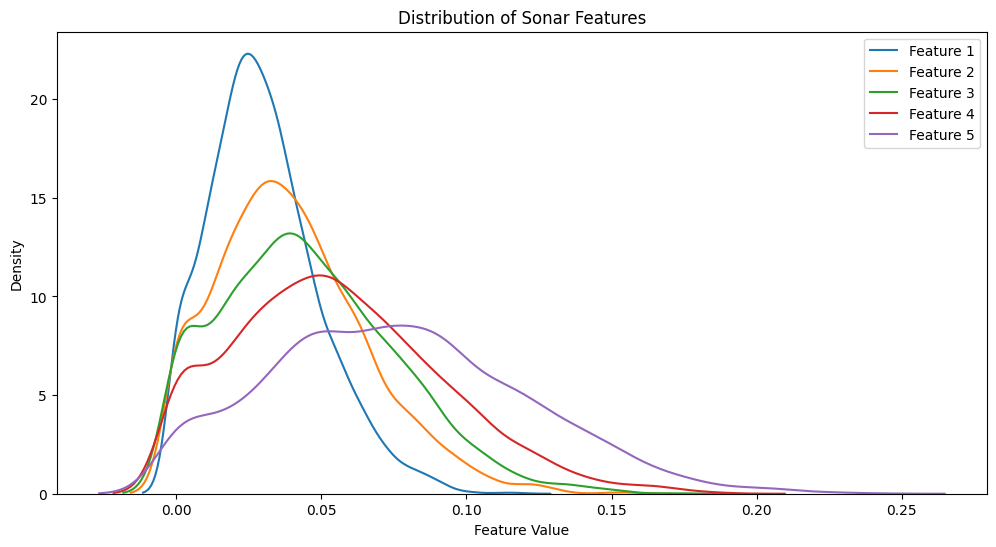

In [138]:
# Feature Distribution (KDE Plot) for Skewness Analysis

# Since there are 60 features, plotting only the first few features

plt.figure(figsize=(12,6))
for i in range(1,6):
  feature = f'Sonar_Feature_{i:02d}'
  sns.kdeplot(
      data = sonar_data,
      x = feature,
      label = f"Feature {i}",
  )

plt.title('Distribution of Sonar Features')
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()

plt.show()

In [139]:
# Skewness Analysis
# Positive values far from 0 are right skewed, 0 is considered as symmetric distribution

skewness = sonar_data.iloc[:,:-1].skew()

print('Top Positively Skewed Features:')
print(skewness.sort_values(ascending = False).head(10))

print('\nTop Negaively Skewed Features:')
print(skewness.sort_values().head(10))

Top Positively Skewed Features:
Sonar_Feature_02    0.672723
Sonar_Feature_01    0.670848
Sonar_Feature_46    0.636614
Sonar_Feature_45    0.629833
Sonar_Feature_51    0.618831
Sonar_Feature_52    0.571006
Sonar_Feature_58    0.558931
Sonar_Feature_03    0.553873
Sonar_Feature_04    0.526056
Sonar_Feature_59    0.512094
dtype: float64

Top Negaively Skewed Features:
Sonar_Feature_27   -0.173548
Sonar_Feature_25   -0.147131
Sonar_Feature_26   -0.140409
Sonar_Feature_29   -0.133522
Sonar_Feature_28   -0.123676
Sonar_Feature_24   -0.122473
Sonar_Feature_23   -0.075214
Sonar_Feature_22   -0.069483
Sonar_Feature_30   -0.042708
Sonar_Feature_21    0.005336
dtype: float64


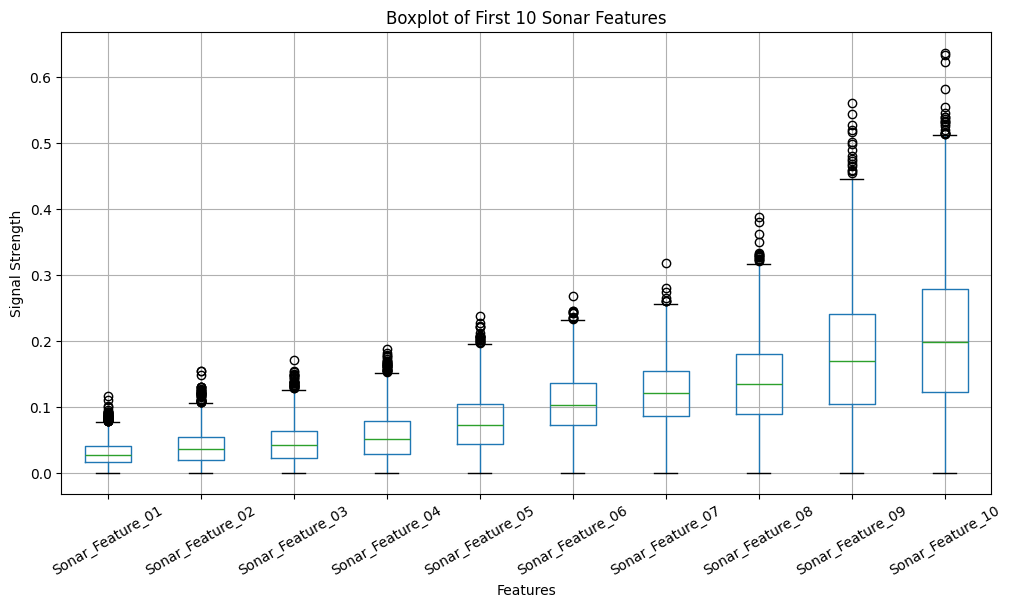

In [140]:
# Feature Distribution (Box Plot) for Outlier Analysis

sonar_data.iloc[:,:10].boxplot(figsize=(12,6))
plt.title('Boxplot of First 10 Sonar Features')
plt.xlabel('Features')
plt.ylabel('Signal Strength')
plt.xticks(rotation = 30)

plt.show()

In [144]:
# Outlier Analysis

Q1 = sonar_data.iloc[:,:-1].quantile(0.25)
Q3 = sonar_data.iloc[:,:-1].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((sonar_data.iloc[:,:-1] < lower_bound) | (sonar_data.iloc[:,:-1] > upper_bound))

outliers_count = outliers.sum()

print(f"Total Outliers: {outliers_count.sum()}")
print('\nFeatures with Potential Outliers:')
print(outliers_count[outliers_count>0].sort_values(ascending=False))
# Values which are 0 are not outliers.

Total Outliers: 945

Features with Potential Outliers:
Sonar_Feature_01    50
Sonar_Feature_59    46
Sonar_Feature_45    42
Sonar_Feature_54    41
Sonar_Feature_46    40
Sonar_Feature_02    39
Sonar_Feature_60    35
Sonar_Feature_03    31
Sonar_Feature_44    31
Sonar_Feature_51    31
Sonar_Feature_58    30
Sonar_Feature_04    30
Sonar_Feature_52    27
Sonar_Feature_47    26
Sonar_Feature_55    23
Sonar_Feature_05    21
Sonar_Feature_10    20
Sonar_Feature_53    19
Sonar_Feature_48    18
Sonar_Feature_09    16
Sonar_Feature_11    15
Sonar_Feature_08    15
Sonar_Feature_17    14
Sonar_Feature_43    13
Sonar_Feature_16    12
Sonar_Feature_28    12
Sonar_Feature_39    12
Sonar_Feature_50    11
Sonar_Feature_49    11
Sonar_Feature_33    11
Sonar_Feature_57    11
Sonar_Feature_34    10
Sonar_Feature_40    10
Sonar_Feature_37    10
Sonar_Feature_06    10
Sonar_Feature_15    10
Sonar_Feature_29    10
Sonar_Feature_36     9
Sonar_Feature_42     9
Sonar_Feature_41     9
Sonar_Feature_56     9
So

In [145]:
# Manually Encoding Target Column

sonar_data['Target'] = sonar_data['Target'].replace({'R': 0, 'M': 1})
print(sonar_data['Target'].value_counts())

Target
1    1637
0    1363
Name: count, dtype: int64


In [146]:
# Split data into features (x) and target (y)
x = sonar_data.drop(columns='Target', axis = 1)
y = sonar_data['Target']

In [147]:
# Split data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=42, stratify = y)
# stratify = y: for training and testing sets to preserve approximately the same class distribution

In [148]:
# Create Logistic Regression Pipeline for Baseline Model

baseline_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Handling Null Values
    ('scaler', StandardScaler()), # Standardization
    ('logistic_regression', LogisticRegression(max_iter = 2000))
])

In [149]:
# Create Logistic Regression Pipeline for Yeo-Johnson Model
# Yeo-Johnson Model handles skewness well

yeo_model = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("power_transform", PowerTransformer(method = 'yeo-johnson')), # skewness aware
    ("logistic_regression", LogisticRegression(max_iter = 2000))
])

In [150]:
# Create Logistic Regression Pipeline for Robust Scaler Model
# Robust Scaler handles outliers well

robust_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()), # outlier robust
    ('logistic_regression', LogisticRegression(max_iter=2000))
])

In [151]:
# Model Selection using Cross-Validation Technique

# Reason for using x_train and y_train instead of x and y:
# Taking only training data and spliting it into 5 parts. Training on 4 parts and validating on the remaining part

baseline_score = cross_val_score(
    baseline_model,
    x_train,
    y_train,
    cv = 5,
    scoring = 'f1'
)

yeo_score = cross_val_score(
    yeo_model,
    x_train,
    y_train,
    cv = 5,
    scoring = 'f1'
)

robust_score = cross_val_score(
    robust_model,
    x_train,
    y_train,
    cv=5,
    scoring = 'f1'
)

print(f"Baseline Model's Mean F1 Score: {baseline_score.mean() * 100:.2f}%")
print(f"Yeo Model's Mean F1 Score: {yeo_score.mean() * 100:.2f}%")
print(f"Robust Model's Mean F1 Score: {robust_score.mean() * 100:.2f}%")

Baseline Model's Mean F1 Score: 87.34%
Yeo Model's Mean F1 Score: 86.03%
Robust Model's Mean F1 Score: 86.91%


In [155]:
# PCA + Yeo Johnson Pipeline
# PCA for dimensionality reduction without loosing significant information, here I am retaining 95% of the variance

yeo_pca_model = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('power_transform', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('logistic_regression', LogisticRegression(max_iter=2000))
])

In [156]:
# Cross Validation after applying PCA with Yeo-Johnson Model

yeo_pca_score = cross_val_score(
    yeo_pca_model,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Yeo-Johnson + PCA's Mean F1 Score: {yeo_pca_score.mean()* 100:.2f}%")

Yeo-Johnson + PCA's Mean F1 Score: 85.74%


In [157]:
# Fitting the pipeline to find the number of PCA components

yeo_pca_model.fit(x_train, y_train)

# named_steps allows us to access an individual step using its name.
pca_model = yeo_pca_model.named_steps['pca']

print("Original number of features:", x_train.shape[1])
print("Number of PCA components:", pca_model.n_components_)

# explained_variance_ratio_ tells how much variance each PCA component contributes.
print(f'\nExplained variance ratio:\n{pca_model.explained_variance_ratio_}')

Original number of features: 60
Number of PCA components: 19

Explained variance ratio:
[0.22047775 0.19956334 0.09580033 0.06481218 0.05358033 0.04627564
 0.03871573 0.02996802 0.02667948 0.02631806 0.02165115 0.02103306
 0.01860053 0.01756593 0.01529752 0.01476044 0.01405221 0.01342697
 0.01165777]


In [158]:
# Hyperparameter tuning

param_grid = {
    'logistic_regression__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator = yeo_pca_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)

# Train the model
grid_search.fit(x_train, y_train)

print(f'Best Parameter: {grid_search.best_params_}')
print(f'\nBest Cross-Validation F1 Score: {grid_search.best_score_ * 100:.2f}%')

Best Parameter: {'logistic_regression__C': 0.01}

Best Cross-Validation F1 Score: 85.85%


In [159]:
# Best model

best_model = grid_search.best_estimator_

In [160]:
# Evaluation on Training Data first to understand how well the model has learned.

# Make Predictions on training data
train_data_prediction = best_model.predict(x_train)

# Evaluate the model on training data
accuracy_train = accuracy_score(y_train, train_data_prediction)
precision_train = precision_score(y_train, train_data_prediction, average = 'binary')
recall_train = recall_score(y_train, train_data_prediction, average = 'binary')
f1_score_train = f1_score(y_train, train_data_prediction, average = 'binary')

print('------------- Performance on Training Data -------------\n')
print(f"Accuracy: {accuracy_train * 100:.2f}%")
print(f"Precision: {precision_train * 100:.2f}%")
print(f"Recall: {recall_train * 100:.2f}%")
print(f"F1 Score: {f1_score_train * 100:.2f}%")

------------- Performance on Training Data -------------

Accuracy: 84.83%
Precision: 85.78%
Recall: 86.56%
F1 Score: 86.17%


In [161]:
# Make Predictions on testing data
test_data_prediction = best_model.predict(x_test)

# Evaluate the model on training data
accuracy_test = accuracy_score(y_test, test_data_prediction)
precision_test = precision_score(y_test, test_data_prediction, average = 'binary')
recall_test = recall_score(y_test, test_data_prediction, average = 'binary')
f1_score_test = f1_score(y_test, test_data_prediction, average = 'binary')

print('------------- Final Test Set Performance -------------\n')
print(f"Accuracy: {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall: {recall_test * 100:.2f}%")
print(f"F1 Score: {f1_score_test * 100:.2f}%")

------------- Final Test Set Performance -------------

Accuracy: 85.67%
Precision: 86.40%
Recall: 87.46%
F1 Score: 86.93%


In [162]:
# Compute Confusion Matrix
cm = confusion_matrix(y_test, test_data_prediction)
print('Confusion Matrix:\n',cm)

# 7 Rocks incorrectly classified as Mine
# 5 Mines incorrectly classified as Rock

Confusion Matrix:
 [[228  45]
 [ 41 286]]


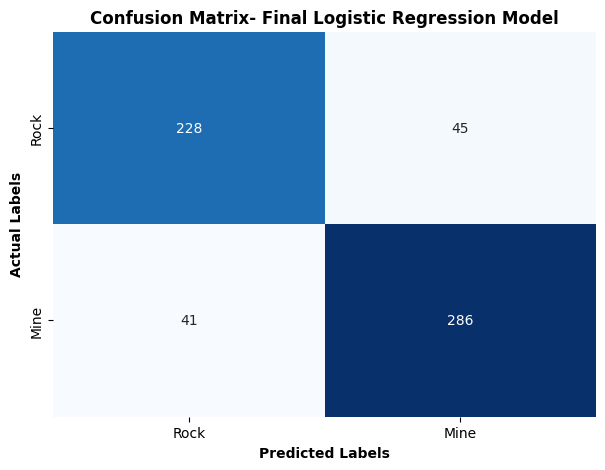

In [163]:
# Plot Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot= True, fmt='d', cmap= 'Blues', cbar=False,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])

# Add labels to the plot
plt.xlabel('Predicted Labels', fontweight='bold')
plt.ylabel('Actual Labels', fontweight='bold')
plt.title('Confusion Matrix- Final Logistic Regression Model', fontweight = 'bold')
plt.show()

In [164]:
# Classification Report
classification_report_test = classification_report(y_test, test_data_prediction, target_names = ['Rock', 'Mine'])
print(classification_report_test)

              precision    recall  f1-score   support

        Rock       0.85      0.84      0.84       273
        Mine       0.86      0.87      0.87       327

    accuracy                           0.86       600
   macro avg       0.86      0.85      0.86       600
weighted avg       0.86      0.86      0.86       600



In [165]:
# ROC-AUC (Receiver Operating Characteristic – Area Under the Curve.)
# It is used mainly for binary classification

y_test_probability = best_model.predict_proba(x_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_test_probability,
)

print(f'ROC-AUC Score: {roc_auc * 100:.2f}%')
# There is 85% chance of assigning a higher probability to the Mine sample, which is good.

ROC-AUC Score: 92.93%


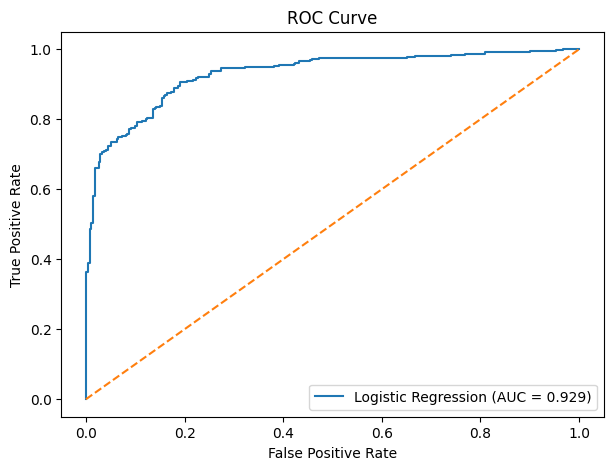

In [166]:
# Plotting ROC-AUC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.show()

In [168]:
# New Sample Prediction

new_sample = pd.DataFrame([[
    0.0200, 0.0371, 0.0428, 0.0207, 0.1954,
    0.0986, 0.4539, 0.1601, 0.3109, 0.2131,
    0.1609, 0.1582, 0.2238, 0.0645, 0.0660,
    0.2273, 0.3100, 0.4997, 0.5078, 0.4797,
    0.5783, 0.5071, 0.4328, 0.9550, 0.0711,
    0.1415, 0.7104, 0.8080, 0.6791, 0.3857,
    0.1307, 0.2604, 0.5125, 0.7547, 0.2537,
    0.8507, 0.6692, 0.3097, 0.4943, 0.2744,
    0.0510, 0.2834, 0.2825, 0.4256, 0.2641,
    0.1386, 0.1051, 0.1343, 0.3383, 0.0324,
    0.0232, 0.0027, 0.0065, 0.0159, 0.0072,
    0.6167, 0.0180, 0.0084, 0.3090, 0.0032
]], columns = x_train.columns)

# Making Predictions
new_pred = best_model.predict(new_sample)

if new_pred[0] == 0:
  print('Prediction: Rock')
else:
  print('Prediction: Mine')

# Prediction Probability
probability = best_model.predict_proba(new_sample)

print(f"Probability of Rock: {probability[0][0] * 100:.2f}%")
print(f"Probability of Mine: {probability[0][1] * 100:.2f}%")

Prediction: Mine
Probability of Rock: 14.32%
Probability of Mine: 85.68%


In [170]:
import joblib

joblib.dump(best_model, 'sonar_final_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [171]:
pip install streamlit joblib pandas numpy scikit-learn

In [172]:
%%writefile app.py

Overwriting app.py


In [173]:
%%writefile requirements.txt

Overwriting requirements.txt


In [132]:
! wget -q -O - ipv4.icanhazip.com

136.85.65.254


In [133]:
! streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇

⠏⠋⠙⠹⠸2026-09-07 07:12:44.695 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.85.65.254:8501

your url is: https://three-falcons-agree.loca.lt
  Stopping...
  Stopping...
^C
